<a href="https://colab.research.google.com/github/Biilzaa/TugasPraktikumANN--AI/blob/main/TugasPraktikumANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA: MUHAMMAD DIWAN ALFARABI,                                      NIM: 09020624050

Tahap ini dilakukan untuk mengimport seluruh library yang dibutuhkan dalam proses klasifikasi menggunakan Artificial Neural Network (ANN), mulai dari pengolahan data, preprocessing, pembangunan model, hingga evaluasi hasil.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

Dataset Drug Classification dimuat ke dalam Google Colab untuk digunakan dalam proses analisis dan pelatihan model ANN.

In [58]:
df = pd.read_csv('drug200.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


Tahap ini bertujuan untuk memahami struktur dataset, tipe data, serta mengecek keberadaan missing value sebelum dilakukan preprocessing.

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [60]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


Karena terdapat data kategorikal, maka dilakukan proses encoding agar data dapat diproses oleh model Artificial Neural Network yang hanya menerima data numerik.

In [61]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['BP'] = le.fit_transform(df['BP'])
df['Cholesterol'] = le.fit_transform(df['Cholesterol'])
df['Drug'] = le.fit_transform(df['Drug'])

In [62]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0


Dataset dipisahkan menjadi variabel fitur (X) dan target (y) untuk proses training model ANN.

In [63]:
X = df.drop('Drug', axis=1)
y = df['Drug']

Data dibagi menjadi data training dan testing untuk melatih model serta menguji performanya pada data yang belum pernah dilihat.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Normalisasi dilakukan agar semua fitur berada pada skala yang sama sehingga proses training ANN menjadi lebih stabil dan optimal.

In [65]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model Artificial Neural Network dibangun menggunakan beberapa hidden layer dengan fungsi aktivasi ReLU. Output layer menggunakan Softmax karena termasuk multi-class classification.

In [66]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(5, activation='softmax')
])

Model dikompilasi menggunakan optimizer Adam dan loss function sparse categorical crossentropy untuk klasifikasi multi-kelas.

In [67]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model dilatih menggunakan data training untuk mempelajari pola hubungan antara fitur pasien dan jenis obat.

In [68]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.0938 - loss: 1.6201 - val_accuracy: 0.0312 - val_loss: 1.7104
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1172 - loss: 1.5996 - val_accuracy: 0.0312 - val_loss: 1.6878
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1406 - loss: 1.5811 - val_accuracy: 0.0938 - val_loss: 1.6722
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1797 - loss: 1.5649 - val_accuracy: 0.1562 - val_loss: 1.6551
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2578 - loss: 1.5491 - val_accuracy: 0.1875 - val_loss: 1.6413
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2969 - loss: 1.5326 - val_accuracy: 0.1875 - val_loss: 1.6294
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3438 - loss: 1.5169 - val_accuracy: 0.1875 - val_loss: 1.6180
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4062 - loss: 1.4991 - val_accuracy: 0.2500 - val_loss:

Tahap ini digunakan untuk mengukur performa model pada data testing menggunakan nilai loss dan accuracy.

In [69]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9750 - loss: 0.2214 
Loss: 0.2214471995830536
Accuracy: 0.9750000238418579


Model digunakan untuk melakukan prediksi terhadap data testing untuk menghasilkan kelas obat yang sesuai.

In [70]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes[:10])

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[4 0 4 3 0 0 0 4 1 4]


Tahap ini digunakan untuk mengevaluasi performa model secara detail. Confusion matrix menunjukkan jumlah prediksi benar dan salah, sedangkan classification report menunjukkan precision, recall, dan f1-score. Parameter zero_division=0 digunakan untuk menghindari warning pada kelas yang tidak terprediksi.

In [71]:
cm = confusion_matrix(y_test, predicted_classes)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[15  0  0  0  0]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 1  0  0  4  0]
 [ 0  0  0  0 11]]


In [72]:
print(classification_report(
    y_test,
    predicted_classes,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3
           3       1.00      0.80      0.89         5
           4       1.00      1.00      1.00        11

    accuracy                           0.97        40
   macro avg       0.99      0.96      0.97        40
weighted avg       0.98      0.97      0.97        40



Grafik accuracy digunakan untuk melihat perkembangan performa model selama proses training dan validation untuk mendeteksi kemungkinan overfitting.

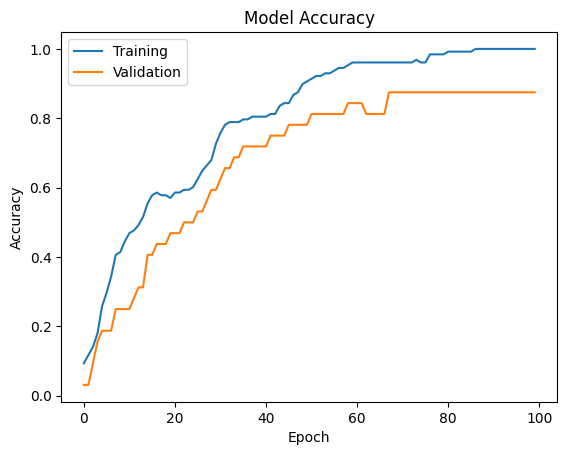

In [73]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training', 'Validation'])
plt.show()

Berdasarkan hasil pengujian, model Artificial Neural Network mampu melakukan klasifikasi jenis obat dengan performa yang cukup baik. Model berhasil mempelajari pola hubungan antara data pasien dan jenis obat berdasarkan fitur seperti usia, jenis kelamin, tekanan darah, kolesterol, dan rasio sodium terhadap potassium.

Hasil training menunjukkan bahwa nilai accuracy meningkat seiring bertambahnya epoch, yang menandakan model mampu belajar dengan baik dari data training. Selain itu, perbedaan antara training accuracy dan validation accuracy tidak terlalu besar, sehingga model tidak mengalami overfitting yang signifikan.

Evaluasi menggunakan confusion matrix menunjukkan bahwa sebagian besar data berhasil diprediksi dengan benar oleh model. Classification report juga menunjukkan nilai precision, recall, dan f1-score yang cukup stabil pada setiap kelas, meskipun terdapat beberapa kelas dengan jumlah prediksi lebih rendah.

Secara keseluruhan, Artificial Neural Network terbukti efektif digunakan untuk klasifikasi multiclass pada dataset Drug Classification karena mampu menghasilkan akurasi yang baik dan pola prediksi yang konsisten.